**Objetivo**

Implementar regresión lineal simple usando NumPy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. GENERACIÓN DE DATOS (Se preserva la semilla para mantener resultados)
generador = np.random.default_rng(seed=42)

n_obs = 100
feat_x = generador.random(n_obs) * 10
ruido = generador.normal(0, 1, n_obs) * 1.5

# Modelo real: y = 2x + 3 + ruido
target_y = 2 * feat_x + 3 + ruido

print("\n--- Primeros 5 valores ---")
print(f"X: {feat_x[:5]}")
print(f"Y: {target_y[:5]}")


--- Primeros 5 valores ---
X: [7.73956049 4.3887844  8.5859792  6.97368029 0.94177348]
Y: [19.07878231 10.41935021 19.60471457 18.89620303  4.349151  ]


In [ ]:
# 2. CÁLCULOS ESTADÍSTICOS BÁSICOS
mu_x = np.mean(feat_x)
mu_y = np.mean(target_y)

suma_cuadrados_x = np.sum((feat_x - mu_x)**2)
var_poblacional_x = suma_cuadrados_x / n_obs

print("\nVar(x):", var_poblacional_x)

suma_productos_xy = np.sum((feat_x - mu_x) * (target_y - mu_y))

# Coeficientes
pendiente = suma_productos_xy / suma_cuadrados_x
interseccion = mu_y - pendiente * mu_x

print("Pendiente (β1):", pendiente)      # ~2
print("Intersección (β0):", interseccion) # ~3

# Predicciones con la fórmula escalar
y_hat_escalar = interseccion + pendiente * feat_x

# Métricas de error
suma_cuadrados_residuales = np.sum((target_y - y_hat_escalar)**2)
suma_cuadrados_totales = np.sum((target_y - mu_y)**2)

error_cuadratico_medio = np.mean((target_y - y_hat_escalar)**2)
coef_determinacion = 1 - (suma_cuadrados_residuales / suma_cuadrados_totales) # Sintaxis alternativa R2
raiz_ecm = np.sqrt(error_cuadratico_medio)
error_absoluto_medio = np.mean(np.abs(target_y - y_hat_escalar))
error_porcentual_medio = np.mean(np.abs(target_y - y_hat_escalar) / target_y) * 100

print(f"\nMétricas de evaluación:")
print(f"MAE:  {error_absoluto_medio:.4f}")
print(f"MAPE: {error_porcentual_medio:.4f}%")
print(f"MSE:  {error_cuadratico_medio:.4f}")
print(f"R²:   {coef_determinacion:.4f}")
print(f"RMSE: {raiz_ecm:.4f}")


Var(x): 7.411902917506793
Pendiente (β1): 2.0114944382203186
Intersección (β0): 2.923049589825455

Métricas de evaluación:
MAE:  1.1874
MAPE: 11.7794%
MSE:  2.1574
R²:   0.9329
RMSE: 1.4688


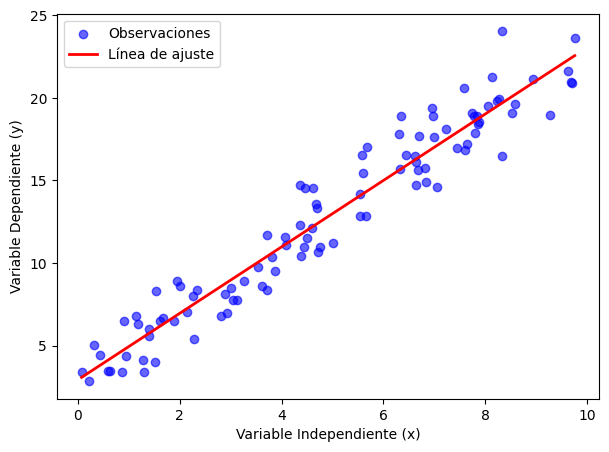

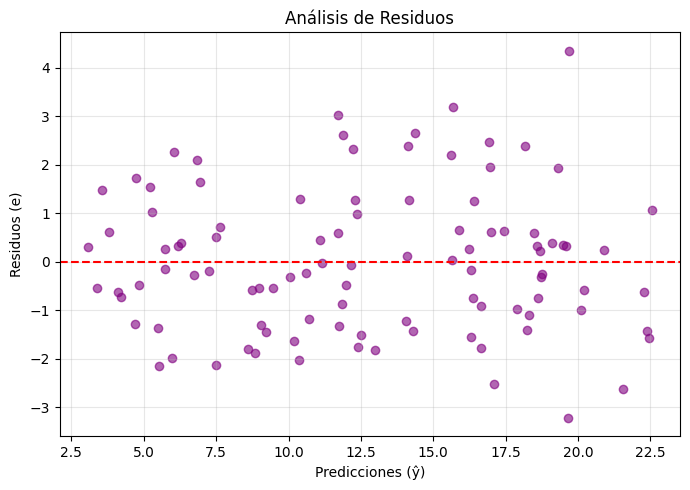


Media de residuos: 0.000000
Varianza de residuos: 2.157444


In [ ]:
# 3. GRÁFICOS (Usando sintaxis orientada a objetos: fig, ax)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(feat_x, target_y, alpha=0.6, label="Observaciones", color="blue")

x_rango = np.array([feat_x.min(), feat_x.max()])
y_rango = interseccion + pendiente * x_rango
ax.plot(x_rango, y_rango, color="red", linewidth=2, label="Línea de ajuste")

ax.set_xlabel("Variable Independiente (x)")
ax.set_ylabel("Variable Dependiente (y)")
ax.legend()
plt.show()

# Residuos escalares
residuos = target_y - y_hat_escalar

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.scatter(y_hat_escalar, residuos, alpha=0.6, color="purple")
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_xlabel('Predicciones (ŷ)')
ax2.set_ylabel('Residuos (e)')
ax2.set_title('Análisis de Residuos')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Usando .item() para extraer el valor numérico con seguridad
media_residuos = np.mean(residuos).item()
varianza_residuos = np.var(residuos).item()

print(f"\nMedia de residuos: {media_residuos:.6f}")
print(f"Varianza de residuos: {varianza_residuos:.6f}")

In [ ]:
# 4. SOLUCIÓN CERRADA CON ÁLGEBRA MATRICIAL
print("\n" + "="*40)
print("ÁLGEBRA MATRICIAL (Solución Cerrada)")
print("="*40)

# Crear matriz de diseño usando np.column_stack en lugar de np.c_
Matriz_X = np.column_stack((np.ones(n_obs), feat_x))

print("\nPrimeras 5 filas de la Matriz de Diseño X:")
print(Matriz_X[:5])

# Operaciones matriciales
X_trans_X = Matriz_X.T @ Matriz_X
X_trans_y = Matriz_X.T @ target_y
inv_X_trans_X = np.linalg.inv(X_trans_X)

# Vector de pesos (β)
weights = inv_X_trans_X @ X_trans_y

print(f"\nVector de Pesos (β) = (X^T · X)^(-1) · X^T · y")
print(f"β_0 (Intersección) = {weights[0]}")
print(f"β_1 (Pendiente)    = {weights[1]}")
print(f"Error en β_0 respecto al real (3): {abs(weights[0] - 3)}")
print(f"Error en β_1 respecto al real (2): {abs(weights[1] - 2)}")


ÁLGEBRA MATRICIAL (Solución Cerrada)

Primeras 5 filas de la Matriz de Diseño X:
[[1.         7.73956049]
 [1.         4.3887844 ]
 [1.         8.5859792 ]
 [1.         6.97368029]
 [1.         0.94177348]]

Vector de Pesos (β) = (X^T · X)^(-1) · X^T · y
β_0 (Intersección) = 2.923049589825416
β_1 (Pendiente)    = 2.011494438220326
Error en β_0 respecto al real (3): 0.07695041017458415
Error en β_1 respecto al real (2): 0.011494438220326142


In [ ]:
# 5. PREDICCIONES Y RESIDUOS MATRICIALES
y_hat_vec = Matriz_X @ weights

print(f"\nPredicciones vs Reales (Primeros 10):")
print(f"{'Real':>8} | {'Predicho':>8} | {'Residuo':>8}")
print("-" * 30)
for i in range(10):
    print(f"{target_y[i]:8.2f} | {y_hat_vec[i]:8.2f} | {target_y[i] - y_hat_vec[i]:8.3f}")

vector_error = target_y - y_hat_vec

print(f"\nMedia del vector error: {np.mean(vector_error)}")
print(f"Suma del vector error: {np.sum(vector_error)}")

# Verificación de ortogonalidad (X^T · e = 0)
X_trans_error = Matriz_X.T @ vector_error
print(f"\nX^T · e =\n{X_trans_error}")
print(f"¿Es aproximadamente cero? {np.allclose(X_trans_error, 0, atol=1e-10)}")

print(f"Ortogonalidad (columna por columna):")
print(f"Suma de errores (Col 1): {X_trans_error[0]:.10f}")
print(f"X · e (Col 2): {X_trans_error[1]:.10f}")


Predicciones vs Reales (Primeros 10):
    Real | Predicho |  Residuo
------------------------------
   19.08 |    18.49 |    0.588
   10.42 |    11.75 |   -1.332
   19.60 |    20.19 |   -0.589
   18.90 |    16.95 |    1.946
    4.35 |     4.82 |   -0.468
   23.62 |    22.55 |    1.071
   16.82 |    18.23 |   -1.411
   18.41 |    18.73 |   -0.322
    4.14 |     5.50 |   -1.363
   11.50 |    11.98 |   -0.483

Media del vector error: 3.832489881006041e-15
Suma del vector error: 3.8324898810060404e-13

X^T · e =
[ 3.83693077e-13 -4.19575485e-12]
¿Es aproximadamente cero? True
Ortogonalidad (columna por columna):
Suma de errores (Col 1): 0.0000000000
X · e (Col 2): -0.0000000000


In [ ]:
# 6. MATRIZ DE PROYECCIÓN (Matriz Hat o H)
Proj_mat = Matriz_X @ inv_X_trans_X @ Matriz_X.T

print(f"\nDimensiones de Matriz Proyección H: {Proj_mat.shape}")

# Verificaciones matemáticas de H
es_simetrica = np.allclose(Proj_mat, Proj_mat.T)
es_idempotente = np.allclose(Proj_mat, Proj_mat @ Proj_mat)
traza_proyeccion = np.trace(Proj_mat)

print(f"H es simétrica: {es_simetrica}")
print(f"H es idempotente (H² = H): {es_idempotente}")
print(f"Traza(H) = {traza_proyeccion:.6f} (Debería ser igual a p=2)")

# Comprobar que H · y = ŷ
H_por_y = Proj_mat @ target_y
print(f"\n¿H·y es igual a las predicciones ŷ? {np.allclose(H_por_y, y_hat_vec, atol=1e-10)}")


Dimensiones de Matriz Proyección H: (100, 100)
H es simétrica: True
H es idempotente (H² = H): True
Traza(H) = 2.000000 (Debería ser igual a p=2)

¿H·y es igual a las predicciones ŷ? True


In [ ]:
# 7. TEOREMA DE PITÁGORAS ESTADÍSTICO (SST = SSR + SSE)
# Utilizamos .item() para forzar un flotante escalar puro y evitar errores de indexación

SS_Total = (target_y.T @ target_y - n_obs * (np.mean(target_y))**2).item()
SS_Regresion = (y_hat_vec.T @ y_hat_vec - n_obs * (np.mean(target_y))**2).item()
SS_Error = (vector_error.T @ vector_error).item()

print("\nDescomposición de la Varianza (Matrices):")
print(f"SS Total (SST)      = {SS_Total:.4f}")
print(f"SS Explicada (SSR)  = {SS_Regresion:.4f}")
print(f"SS Residual (SSE)   = {SS_Error:.4f}")

print(f"\nVerificación SST = SSR + SSE:")
print(f"SST           = {SS_Total:.4f}")
print(f"SSR + SSE     = {SS_Regresion + SS_Error:.4f}")
print(f"Diferencia    = {SS_Total - (SS_Regresion + SS_Error):.10f}")
print(f"¿Se cumple la igualdad? {np.allclose(SS_Total, SS_Regresion + SS_Error, atol=1e-10)}")

# R Cuadrado usando matrices
R2_matricial = SS_Regresion / SS_Total
R2_alternativo = 1 - (SS_Error / SS_Total)

print(f"\nR² (SSR/SST)     = {R2_matricial:.4f}")
print(f"R² (1 - SSE/SST) = {R2_alternativo:.4f}")


Descomposición de la Varianza (Matrices):
SS Total (SST)      = 3214.6818
SS Explicada (SSR)  = 2998.9374
SS Residual (SSE)   = 215.7444

Verificación SST = SSR + SSE:
SST           = 3214.6818
SSR + SSE     = 3214.6818
Diferencia    = -0.0000000000
¿Se cumple la igualdad? True

R² (SSR/SST)     = 0.9329
R² (1 - SSE/SST) = 0.9329


In [ ]:
from google.colab import files
from nbconvert import HTMLExporter
import nbformat

# Cargar el archivo .ipynb en el cuaderno
direccion_nombre ='/content/drive/MyDrive/Actividad 1 (Regresión lineal simple).ipynb' # Reemplaza con el nombre de tu cuaderno

# Leer el archivo .ipynb

with open(direccion_nombre) as f:
     contenido = f.read()

# Convertir a HTML
leer_cuaderno = nbformat.reads(contenido, as_version=4)
html_exportar = HTMLExporter()

#html_exporter.exclude_input = False  # Excluye el código si es necesario
html_contenido, _ = html_exportar.from_notebook_node(leer_cuaderno)

# Guardar el archivo HTML

with open('/content/drive/MyDrive/Actividad 1 (Regresión lineal simple).html', 'w') as f:
    f.write(html_contenido)

# Descargar el archivo HTML
files.download('/content/drive/MyDrive/Actividad 1 (Regresión lineal simple).html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>